# Loan Default Classification: Finding Risk in an Imbalanced Dataset
**Module 3 · Supervised Machine Learning**  
**Prepared by: Sanchita Senapati**

### Project overview
Can employment status, recorded bank balance, and annual salary help identify customers who default? This notebook compares **Logistic Regression, Random Forest, RBF Support Vector Machine, and XGBoost**, then examines the trade-off between missed defaults and false alarms.

The supplied report and notebook define the project topic and model families. This implementation uses an original workflow: a majority-class baseline, separate validation and test partitions, precision–recall analysis, validation-based threshold selection, and explanations computed from the results.

**Run instructions:** Open in Jupyter, VS Code, or Colab and run all cells in order. An exact snapshot of the supplied CSV is embedded, so there is no separate dataset download step. If imports fail, uncomment the install command below. Training may take a few minutes. Saved outputs can be viewed directly on GitHub.

**Scope:** This is an educational classification study, not a system for making lending decisions. The source does not establish the population, observation period, currency, or operational meaning of every financial field.

In [1]:
# Uncomment if packages are missing:
# %pip install numpy pandas matplotlib scikit-learn xgboost
import io, base64, zlib, hashlib, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn, xgboost
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    fbeta_score, roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report)
from sklearn.inspection import permutation_importance

SEED = 42
plt.rcParams.update({'figure.figsize': (9, 4.5), 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})
PALETTE = ['#286A89', '#D58A31', '#63936A', '#9A689A']
print(f'Python {sys.version.split()[0]} | pandas {pd.__version__} | '
      f'scikit-learn {sklearn.__version__} | XGBoost {xgboost.__version__}')

Python 3.12.14 | pandas 2.2.3 | scikit-learn 1.8.0 | XGBoost 3.4.1


## 1. Data source and meaning
The linked CSV contains five columns:

| Column | Role in this notebook |
|---|---|
| `Index` | Row identifier, excluded from model inputs |
| `Employed` | Binary feature; the supplied report describes 1 as employed |
| `Bank Balance` | Numeric financial feature, retained under its supplied name |
| `Annual Salary` | Numeric annual income feature |
| `Defaulted?` | Target: 1 = default, 0 = no default |

The next cell decodes the original CSV snapshot and verifies its SHA-256 checksum. Compression only reduces file size; it does not change observations. The snapshot is used to keep reruns independent of future changes to the GitHub branch.

In [2]:
SOURCE_URL = "https://github.com/aamir-gk2539-byte/DSML-Training/blob/main/Module%203%20Project%20Data.csv"
DATA_SHA256 = "1ad4d42251805b605ec7c5fa875fba86365bbe7e484e6b9690c1be37506a1279"
# Compressed copy of the supplied CSV, not simulated data.
CSV_SNAPSHOT = "..."
csv_bytes = zlib.decompress(base64.b64decode(CSV_SNAPSHOT))
assert hashlib.sha256(csv_bytes).hexdigest() == DATA_SHA256
raw = pd.read_csv(io.BytesIO(csv_bytes))
print(f'Loaded {raw.shape[0]:,} rows and {raw.shape[1]} columns.')
display(raw.head())

Loaded 10,000 rows and 5 columns.


,Index,Employed,Bank Balance,Annual Salary,Defaulted?
0,1,1,8754.36,532339.56,0
1,2,0,9806.16,145273.56,0
2,3,1,12882.60,381205.68,0
3,4,1,6351.00,428453.88,0
4,5,1,9427.92,461562.00,0


## 2. Validate before modelling
Check schema, missingness, duplicate identifiers, binary labels, and numeric ranges. Identical feature values can belong to different customers, so they are not automatically deleted. Missing targets are not imputed. Feature imputation is fitted only on training data inside each model pipeline; it is included for reproducibility even though this snapshot has no missing values.

In [3]:
required = ['Index', 'Employed', 'Bank Balance', 'Annual Salary', 'Defaulted?']
assert set(raw.columns) == set(required), 'Unexpected dataset schema.'
quality = pd.DataFrame({'dtype': raw.dtypes.astype(str),
    'missing': raw.isna().sum(), 'unique_values': raw.nunique()})
display(quality)
assert raw['Index'].notna().all() and raw['Index'].is_unique, 'Check customer identifiers.'
assert raw['Defaulted?'].notna().all() and set(raw['Defaulted?'].unique()) == {0, 1}
assert raw['Employed'].dropna().isin([0, 1]).all()
assert (raw[['Bank Balance', 'Annual Salary']].dropna() >= 0).all().all()
assert np.isfinite(raw.select_dtypes(include='number').dropna().to_numpy()).all()
print('Exact duplicate rows:', raw.duplicated().sum())
print('Repeated feature/target profiles:', raw.drop(columns='Index').duplicated().sum())
data = raw.rename(columns={'Bank Balance': 'bank_balance', 'Annual Salary': 'annual_salary',
                          'Employed': 'employed', 'Defaulted?': 'defaulted'})
FEATURES = ['employed', 'bank_balance', 'annual_salary']
X, y = data[FEATURES], data['defaulted'].astype(int)
display(X.describe().round(2))

Exact duplicate rows: 0
Repeated feature/target profiles: 0


,dtype,missing,unique_values
Index,int64,0,10000
Employed,int64,0,2
Bank Balance,float64,0,9227
Annual Salary,float64,0,9989
Defaulted?,int64,0,2


,employed,bank_balance,annual_salary
count,10000.00,10000.00,10000.00
mean,0.71,10024.50,402203.78
std,0.46,5804.58,160039.67
min,0.00,0.00,9263.64
25%,0.00,5780.79,256085.52
50%,1.00,9883.62,414631.74
75%,1.00,13995.66,525692.76
max,1.00,31851.84,882650.76


## 3. Reserve validation and test data
Use stratified **60% training / 20% validation / 20% test** partitions. Stratification approximately preserves the rare default class in every partition.

- Training data: exploration, preprocessing fits, and model fitting.
- Validation data: select the model using **average precision (AP)** and choose its classification threshold.
- Test data: one final evaluation after those choices are frozen.

AP summarises precision and recall across score thresholds and is useful when defaults are rare. ROC-AUC is reported as a complementary ranking measure. We do not choose the winner by test results.

In [4]:
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=.20,
    random_state=SEED, stratify=y)
X_train, X_valid, y_train, y_valid = train_test_split(X_dev, y_dev, test_size=.25,
    random_state=SEED, stratify=y_dev)
assert set(X_train.index).isdisjoint(X_valid.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_valid.index).isdisjoint(X_test.index)
split_summary = pd.DataFrame([
    {'partition': name, 'records': len(labels), 'defaults': int(labels.sum()),
     'default_rate': labels.mean()}
    for name, labels in [('Training', y_train), ('Validation', y_valid), ('Test', y_test)]
]).set_index('partition')
display(split_summary)
train_view = X_train.assign(defaulted=y_train)
print(f'Training majority-class accuracy would be {1 - y_train.mean():.2%}, '
      'while default recall would be 0%.')

Training majority-class accuracy would be 96.67%, while default recall would be 0%.


,records,defaults,default_rate
partition,,,
Training,6000,200,0.033333
Validation,2000,66,0.033000
Test,2000,67,0.033500


## 4. Explore the training partition
The plots below examine imbalance and relationships without using held-out outcomes to guide model design. Correlation measures association, not causation. In particular, the label “Bank Balance” is not sufficient to infer whether it measures savings, outstanding debt, or another accounting balance.

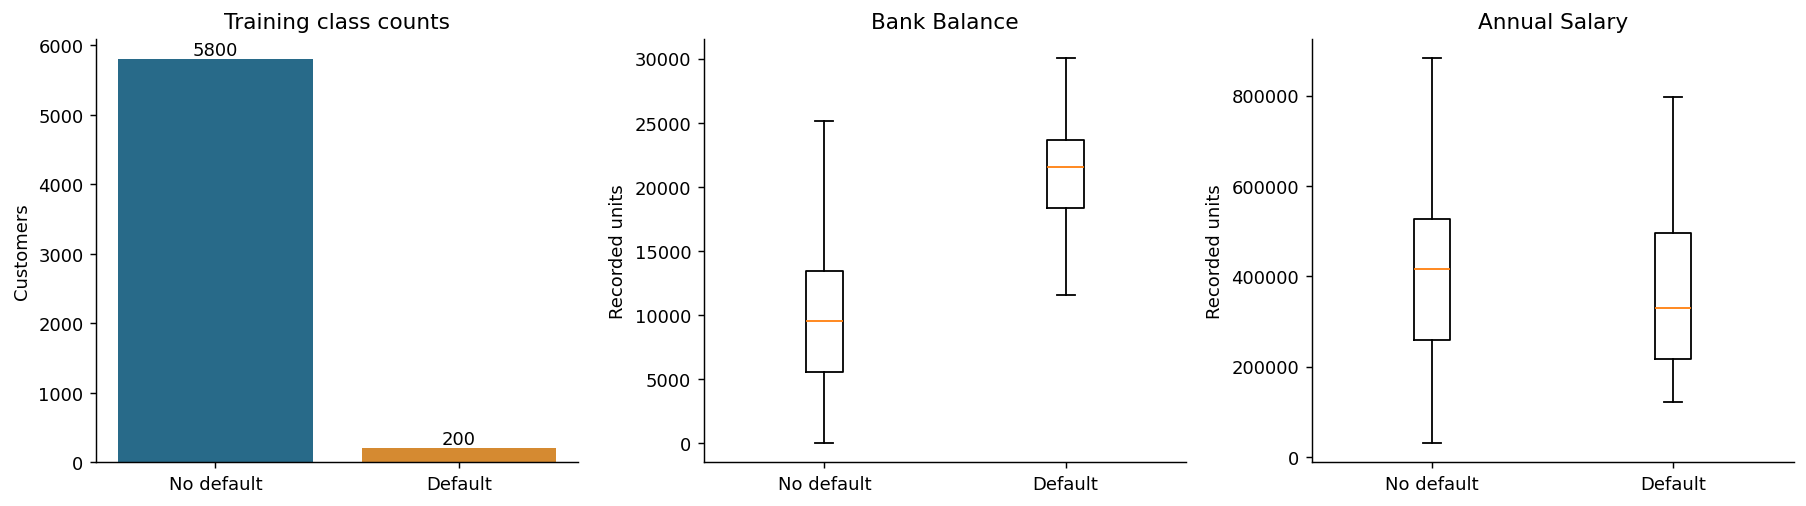

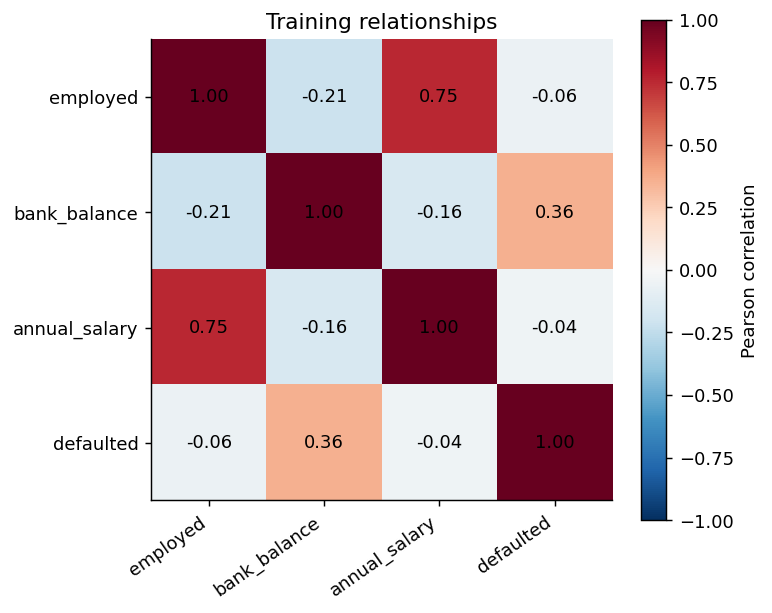

The training correlation between recorded balance and default is **+0.357**. In this dataset, larger recorded balances are associated with more defaults. This corrects the opposite direction described in the reference; it does not establish a causal mechanism.

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
counts = y_train.value_counts().reindex([0, 1])
axes[0].bar(['No default', 'Default'], counts, color=PALETTE[:2])
axes[0].set(title='Training class counts', ylabel='Customers')
for i, count in enumerate(counts): axes[0].text(i, count + 60, str(count), ha='center')
for ax, feature in zip(axes[1:], ['bank_balance', 'annual_salary']):
    ax.boxplot([train_view.loc[y_train.eq(label), feature] for label in [0, 1]],
               tick_labels=['No default', 'Default'], showfliers=False)
    ax.set(title=feature.replace('_', ' ').title(), ylabel='Recorded units')
fig.tight_layout()
plt.show()
correlations = train_view.corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(correlations, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(4), correlations.columns, rotation=35, ha='right')
ax.set_yticks(range(4), correlations.index)
for row in range(4):
    for col in range(4): ax.text(col, row, f'{correlations.iloc[row, col]:.2f}', ha='center', va='center')
fig.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_title('Training relationships')
fig.tight_layout()
plt.show()
balance_corr = correlations.loc['bank_balance', 'defaulted']
display(Markdown(f'The training correlation between recorded balance and default is '
    f'**{balance_corr:+.3f}**. In this dataset, larger recorded balances are associated '
    'with more defaults. This corrects the opposite direction described in the reference; '
    'it does not establish a causal mechanism.'))

## 5. Fit four classifiers and a baseline
All models receive the same three predictors. Median imputation and scaling are fitted within pipelines on the training partition. Logistic Regression and SVM are scaled; tree models use the original scales.

Balanced class weights increase the training penalty for minority-class errors. XGBoost uses the training non-default/default ratio. Class weighting does not guarantee high recall or calibrated probabilities.

Hyperparameters below are fixed educational choices, not the result of an exhaustive search. For SVM, we evaluate the decision function directly: its zero threshold is the default classification boundary, and scores need not be probabilities to calculate AP or ROC-AUC.

In [6]:
def make_pipeline(estimator, scale=False):
    steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale: steps.append(('scaler', StandardScaler()))
    return Pipeline(steps + [('classifier', estimator)])

models = {
    'Logistic Regression': make_pipeline(LogisticRegression(C=1, max_iter=2000,
        class_weight='balanced', random_state=SEED), scale=True),
    'Random Forest': make_pipeline(RandomForestClassifier(n_estimators=250,
        min_samples_leaf=3, class_weight='balanced', random_state=SEED, n_jobs=2)),
    'RBF SVM': make_pipeline(SVC(C=1, kernel='rbf', class_weight='balanced'), scale=True),
    'XGBoost': make_pipeline(XGBClassifier(n_estimators=250, max_depth=3,
        learning_rate=.05, subsample=.9, colsample_bytree=1.0,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric='logloss', tree_method='hist', random_state=SEED, n_jobs=2))
}
baseline = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
def model_scores(model, features):
    if hasattr(model, 'predict_proba'): return model.predict_proba(features)[:, 1]
    return model.decision_function(features)

def metrics(labels, predicted, scores):
    return {'accuracy': accuracy_score(labels, predicted),
        'precision': precision_score(labels, predicted, zero_division=0),
        'recall': recall_score(labels, predicted, zero_division=0),
        'F1': f1_score(labels, predicted, zero_division=0),
        'F2': fbeta_score(labels, predicted, beta=2, zero_division=0),
        'ROC_AUC': roc_auc_score(labels, scores),
        'AP': average_precision_score(labels, scores)}

validation_rows, valid_scores = {}, {}
for name, model in models.items():
    model.fit(X_train, y_train)
    valid_scores[name] = model_scores(model, X_valid)
    validation_rows[name] = metrics(y_valid, model.predict(X_valid), valid_scores[name])
    print('Fitted:', name)
validation_results = pd.DataFrame(validation_rows).T.sort_values('AP', ascending=False)
display(validation_results.round(4))
selected_name = validation_results.index[0]
selected_model = models[selected_name]
print('Selected using validation AP:', selected_name)

Fitted: Logistic Regression
Fitted: Random Forest
Fitted: RBF SVM
Fitted: XGBoost
Selected using validation AP: Logistic Regression


,accuracy,precision,recall,F1,F2,ROC_AUC,AP
Logistic Regression,0.8720,0.1791,0.8030,0.2928,0.4732,0.9352,0.5125
XGBoost,0.8935,0.2024,0.7576,0.3195,0.4892,0.9278,0.5022
Random Forest,0.9625,0.4416,0.5152,0.4755,0.4985,0.9002,0.4789
RBF SVM,0.8600,0.1656,0.8030,0.2746,0.4538,0.9100,0.2910


## 6. Examine ranking quality on validation data
ROC curves compare true-positive and false-positive rates. Precision–recall curves make the false-alarm burden easier to see for the minority class. The dashed PR reference is the validation default prevalence; a random ranking has expected precision near that level.

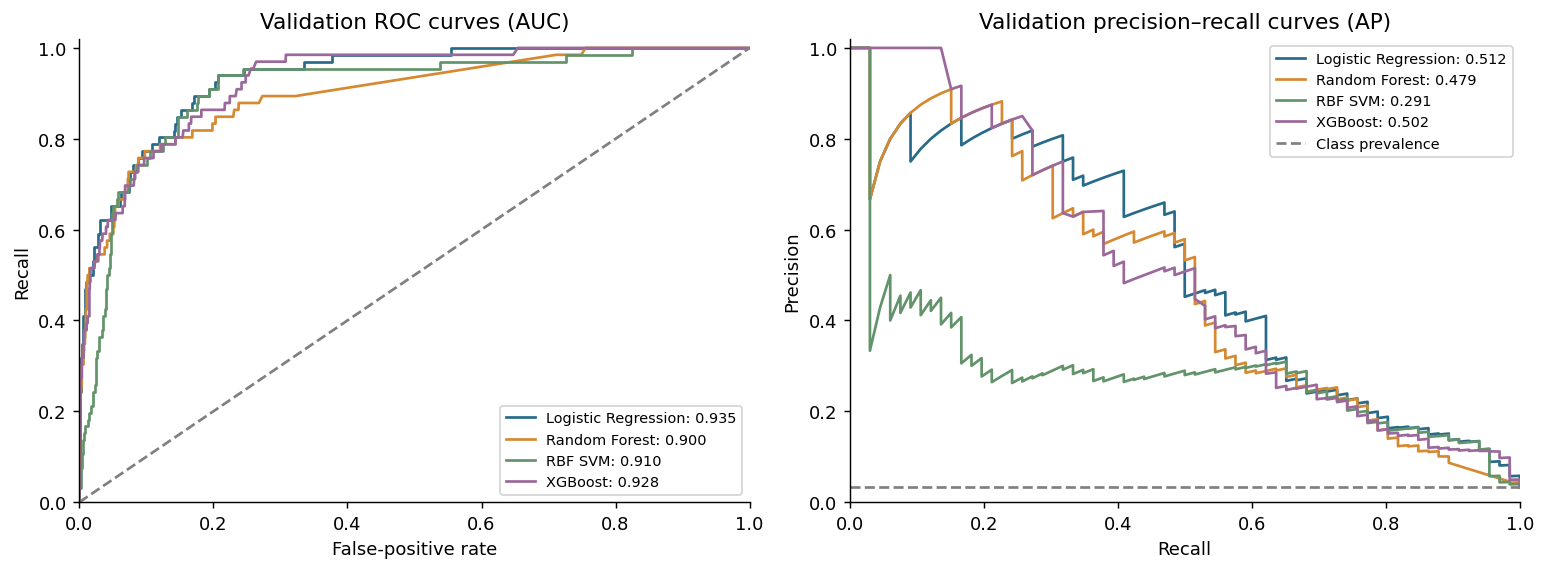

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for (name, scores), color in zip(valid_scores.items(), PALETTE):
    fpr, tpr, _ = roc_curve(y_valid, scores)
    precision, recall, _ = precision_recall_curve(y_valid, scores)
    axes[0].plot(fpr, tpr, color=color, label=f'{name}: {roc_auc_score(y_valid, scores):.3f}')
    axes[1].plot(recall, precision, color=color, label=f'{name}: {average_precision_score(y_valid, scores):.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[1].axhline(y_valid.mean(), ls='--', color='gray', label='Class prevalence')
axes[0].set(title='Validation ROC curves (AUC)', xlabel='False-positive rate', ylabel='Recall')
axes[1].set(title='Validation precision–recall curves (AP)', xlabel='Recall', ylabel='Precision')
for ax in axes: ax.legend(fontsize=8); ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
fig.tight_layout()
plt.show()

## 7. Choose a threshold before looking at test results
For an illustrative screening objective, choose the threshold that maximises validation **F2**, which places more emphasis on recall than precision. This is not a statement that missed defaults cost exactly twice as much; F2 is only a metric preference. Real threshold selection needs verified costs, review capacity, and calibration checks.

The threshold is selected on the same validation set used for model selection, so its validation performance may be optimistic. The untouched test set provides a final check. Ties are resolved by choosing the highest threshold among the maxima. We keep the fitted model unchanged after choosing the threshold.

Selected model: Logistic Regression; locked threshold: 0.87214


,accuracy,precision,recall,F1,F2,ROC_AUC,AP
Default threshold,0.872,0.1791,0.8030,0.2928,0.4732,0.9352,0.5125
Validation F2 threshold,0.958,0.4100,0.6212,0.4940,0.5632,0.9352,0.5125


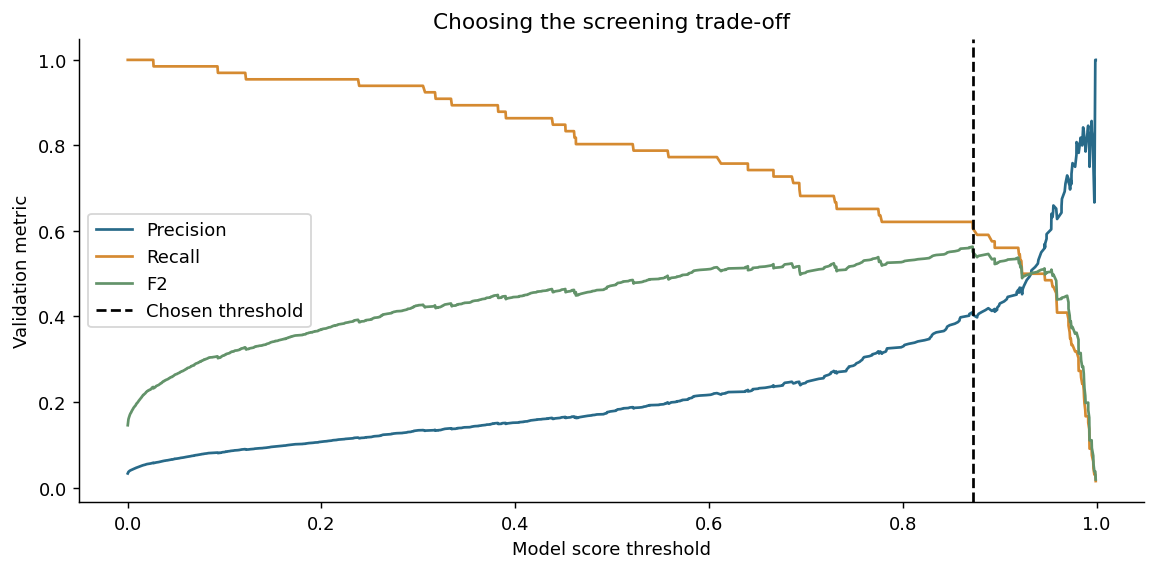

In [8]:
chosen_scores = valid_scores[selected_name]
p, r, thresholds = precision_recall_curve(y_valid, chosen_scores)
f2_values = np.divide(5 * p[:-1] * r[:-1], 4 * p[:-1] + r[:-1],
    out=np.zeros_like(p[:-1]), where=(4 * p[:-1] + r[:-1]) > 0)
best_index = np.flatnonzero(np.isclose(f2_values, f2_values.max()))[-1]
selected_threshold = float(thresholds[best_index])
default_threshold = 0.0 if selected_name == 'RBF SVM' else 0.5
threshold_comparison = pd.DataFrame({
    'Default threshold': metrics(y_valid, (chosen_scores >= default_threshold).astype(int), chosen_scores),
    'Validation F2 threshold': metrics(y_valid, (chosen_scores >= selected_threshold).astype(int), chosen_scores)
}).T
print(f'Selected model: {selected_name}; locked threshold: {selected_threshold:.5f}')
display(threshold_comparison.round(4))
fig, ax = plt.subplots()
ax.plot(thresholds, p[:-1], label='Precision', color=PALETTE[0])
ax.plot(thresholds, r[:-1], label='Recall', color=PALETTE[1])
ax.plot(thresholds, f2_values, label='F2', color=PALETTE[2])
ax.axvline(selected_threshold, ls='--', color='black', label='Chosen threshold')
ax.set(xlabel='Model score threshold', ylabel='Validation metric', title='Choosing the screening trade-off')
ax.legend()
fig.tight_layout()
plt.show()

## 8. Final held-out evaluation
The selected model and threshold are now frozen. For comparison, all four models are also evaluated at their default boundaries, alongside the always-no-default baseline. This table is descriptive: it is not used to reselect a model or tune a threshold.

              precision    recall  f1-score   support

  No default      0.987     0.963     0.975      1933
     Default      0.374     0.642     0.473        67

    accuracy                          0.952      2000
   macro avg      0.681     0.802     0.724      2000
weighted avg      0.967     0.952     0.958      2000

Caught 43 of 67 defaults; missed 24.
Flagged 115 customers, including 72 false alarms.


,accuracy,precision,recall,F1,F2,ROC_AUC,AP
Majority baseline,0.9665,0.0000,0.0000,0.0000,0.0000,0.5000,0.0335
Logistic Regression (default),0.8600,0.1763,0.8657,0.2929,0.4858,0.9479,0.5129
Random Forest (default),0.9605,0.4268,0.5224,0.4698,0.5000,0.9221,0.4738
RBF SVM (default),0.8505,0.1705,0.8955,0.2864,0.4839,0.9200,0.3134
XGBoost (default),0.8825,0.1957,0.8060,0.3149,0.4963,0.9384,0.4605
Logistic Regression (selected threshold),0.9520,0.3739,0.6418,0.4725,0.5614,0.9479,0.5129


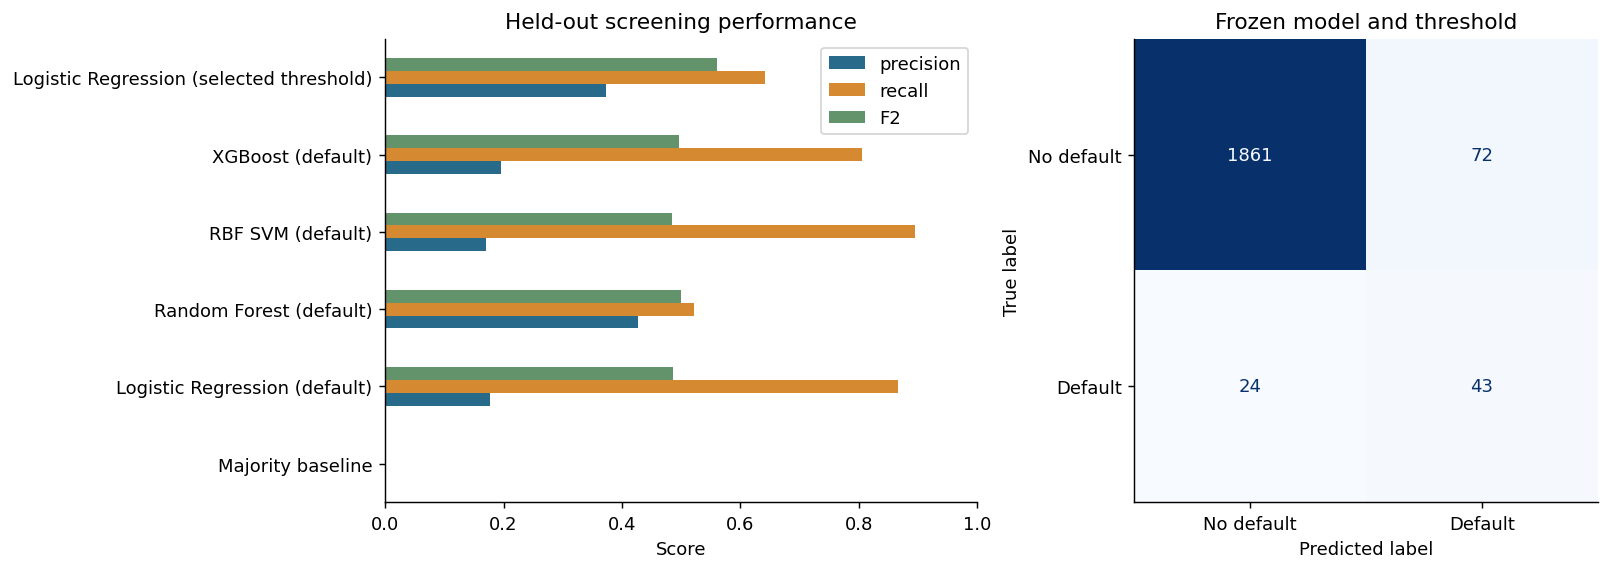

In [9]:
test_rows = {'Majority baseline': metrics(y_test, baseline.predict(X_test),
                                          baseline.predict_proba(X_test)[:, 1])}
for name, model in models.items():
    scores = model_scores(model, X_test)
    test_rows[name + ' (default)'] = metrics(y_test, model.predict(X_test), scores)
test_scores = model_scores(selected_model, X_test)
final_predictions = (test_scores >= selected_threshold).astype(int)
final_label = selected_name + ' (selected threshold)'
test_rows[final_label] = metrics(y_test, final_predictions, test_scores)
test_results = pd.DataFrame(test_rows).T
display(test_results.round(4))
print(classification_report(y_test, final_predictions,
      target_names=['No default', 'Default'], digits=3, zero_division=0))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
test_results[['precision', 'recall', 'F2']].plot.barh(ax=axes[0], color=PALETTE[:3])
axes[0].set(title='Held-out screening performance', xlabel='Score', xlim=(0, 1))
ConfusionMatrixDisplay.from_predictions(y_test, final_predictions,
    display_labels=['No default', 'Default'], cmap='Blues', colorbar=False, ax=axes[1])
axes[1].set_title('Frozen model and threshold')
fig.tight_layout()
plt.show()
tn, fp, fn, tp = confusion_matrix(y_test, final_predictions, labels=[0, 1]).ravel()
print(f'Caught {tp} of {tp + fn} defaults; missed {fn}.')
print(f'Flagged {tp + fp} customers, including {fp} false alarms.')

## 9. Explain predictions without claiming causality
Permutation importance measures how much validation AP drops when a feature is shuffled, keeping the fitted selected model fixed. A larger drop indicates stronger predictive dependence on that feature in this dataset. Correlated features can share information, and a negative estimate can occur through sampling noise.

For Logistic Regression, standardised coefficients additionally describe the direction of association in the weighted fitted model. Tree impurity importances are shown separately for the two tree models; these are not effect sizes and can favour continuous predictors.

Largest measured AP drop: bank_balance


,feature,AP_drop,shuffle_std
1,bank_balance,0.4758,0.0066
0,employed,0.0248,0.0108
2,annual_salary,-0.0074,0.0039


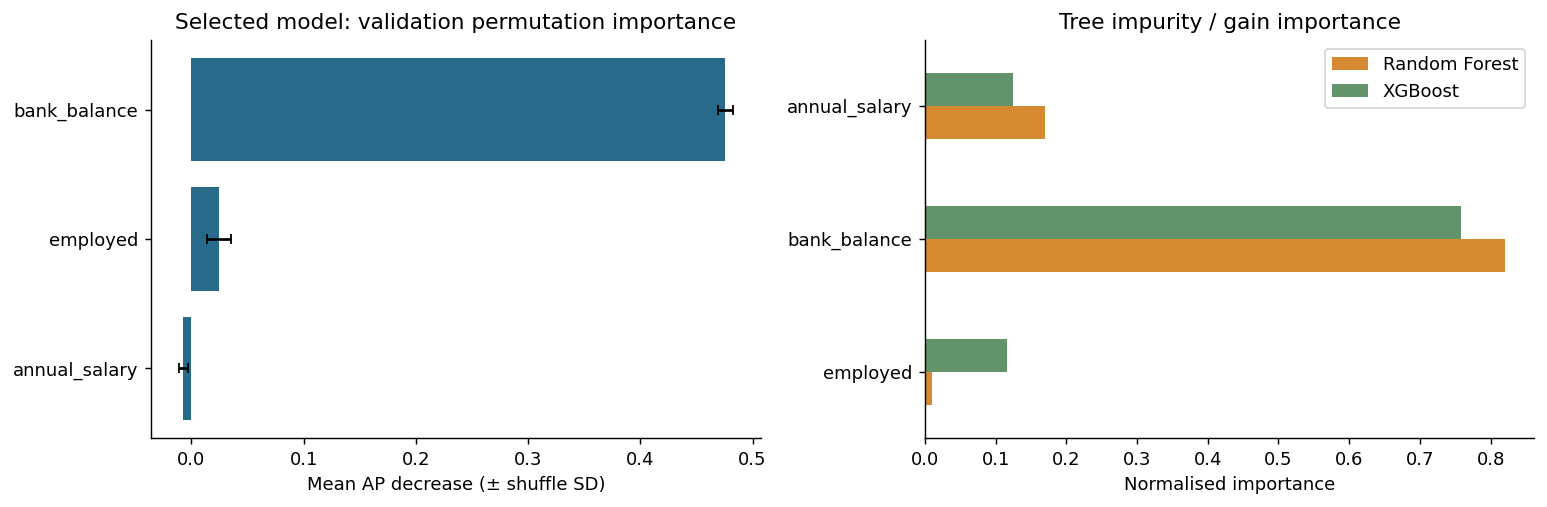

,Standardised logistic coefficient
bank_balance,2.9023
employed,0.3127
annual_salary,-0.1200


In [10]:
importance = permutation_importance(selected_model, X_valid, y_valid,
    scoring='average_precision', n_repeats=8, random_state=SEED, n_jobs=1)
importance_table = pd.DataFrame({'feature': FEATURES,
    'AP_drop': importance.importances_mean, 'shuffle_std': importance.importances_std}
).sort_values('AP_drop', ascending=False)
display(importance_table.round(4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(importance_table.feature[::-1], importance_table.AP_drop[::-1],
    xerr=importance_table.shuffle_std[::-1], color=PALETTE[0], capsize=3)
axes[0].set(title='Selected model: validation permutation importance', xlabel='Mean AP decrease (± shuffle SD)')
tree_importance = pd.DataFrame({name: models[name].named_steps['classifier'].feature_importances_
    for name in ['Random Forest', 'XGBoost']}, index=FEATURES)
tree_importance.plot.barh(ax=axes[1], color=PALETTE[1:3])
axes[1].set(title='Tree impurity / gain importance', xlabel='Normalised importance')
fig.tight_layout()
plt.show()
coefficients = pd.Series(models['Logistic Regression'].named_steps['classifier'].coef_[0],
    index=FEATURES, name='Standardised logistic coefficient').sort_values(ascending=False)
display(coefficients.to_frame().round(4))
print('Largest measured AP drop:', importance_table.iloc[0]['feature'])

## 10. Conclusions generated from this run

In [11]:
final = test_results.loc[final_label]
majority = test_results.loc['Majority baseline']
display(Markdown(f"""
- **Baseline lesson:** always predicting no default achieved **{majority['accuracy']:.2%} accuracy** but **0% recall** for defaults.
- **Model choice:** **{selected_name}** was selected by validation AP, not by looking for the best test score.
- **Held-out ranking:** AP **{final['AP']:.3f}**, ROC-AUC **{final['ROC_AUC']:.3f}**.
- **Locked screening rule:** threshold **{selected_threshold:.4f}** produced precision **{final['precision']:.2%}**, recall **{final['recall']:.2%}**, and F2 **{final['F2']:.3f}**.
- **Operational trade-off:** **{tp}** defaults detected, **{fn}** missed, and **{fp}** false alarms among **{len(y_test):,}** held-out records.
- **Strongest measured feature:** `{importance_table.iloc[0]['feature']}` had the largest mean validation AP decrease under permutation. This is a predictive association, not a causal explanation.

The selected approach is a candidate for further study. The results do not justify automatic approval or rejection of real applicants.
"""))


- **Baseline lesson:** always predicting no default achieved **96.65% accuracy** but **0% recall** for defaults.
- **Model choice:** **Logistic Regression** was selected by validation AP, not by looking for the best test score.
- **Held-out ranking:** AP **0.513**, ROC-AUC **0.948**.
- **Locked screening rule:** threshold **0.8721** produced precision **37.39%**, recall **64.18%**, and F2 **0.561**.
- **Operational trade-off:** **43** defaults detected, **24** missed, and **72** false alarms among **2,000** held-out records.
- **Strongest measured feature:** `bank_balance` had the largest mean validation AP decrease under permutation. This is a predictive association, not a causal explanation.

The selected approach is a candidate for further study. The results do not justify automatic approval or rejection of real applicants.


## 11. Limitations and next steps
- Only three predictors are available, and the dataset's population, timing, and collection process are not documented here. Do not claim real-world representativeness.
- One random split is not a stability study. Stratified cross-validation within development data would help assess variation and tune hyperparameters.
- The held-out partition contains relatively few defaults. Recall and precision may move noticeably when only a few cases change.
- Class-weighted model scores should not be interpreted as calibrated default probabilities. Assess calibration separately if probability estimates are required.
- Before deployment, establish data provenance, confirm feature meanings, examine demographic fairness with appropriate data, and validate on a later time period.
- Set thresholds using agreed error costs and manual-review capacity. F2 here is an explicitly chosen educational objective.

## References and reproducibility
The data, project scope, and model families come from the materials supplied by the user:

1. [Module 3 dataset](https://github.com/aamir-gk2539-byte/DSML-Training/blob/main/Module%203%20Project%20Data.csv)
2. [Reference notebook](https://github.com/aamir-gk2539-byte/DSML-Training/blob/main/Module%203%20Project%20Python%20Code.ipynb)
3. [Reference report](https://github.com/aamir-gk2539-byte/DSML-Training/blob/main/Module%203%20Project%20Report.pdf)

Accessed 6 October 2026. This notebook independently implements the workflow and recomputes all results. It does not copy the reference's reported scores or conclusion. Different split sizes, hyperparameters, ranking criteria, and threshold choices mean the numbers need not match the sample.

For GitHub, upload this single `.ipynb` file. Keep source attribution with the embedded dataset. The dependency versions used for saved results appear in the first output; random seeds and the CSV checksum are recorded in code.